In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

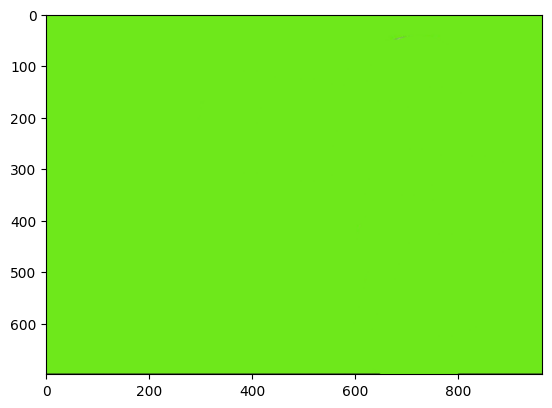

In [16]:
bg_image1 = cv2.imread('images/bg_image1.png')

plt.imshow(cv2.cvtColor(bg_image1, cv2.COLOR_BGR2RGB))
plt.show()

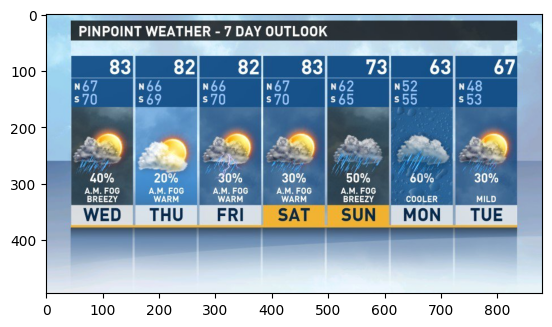

In [17]:
bg_image2 = cv2.imread('images/bg_image2.png')

plt.imshow(cv2.cvtColor(bg_image2, cv2.COLOR_BGR2RGB))
plt.show()

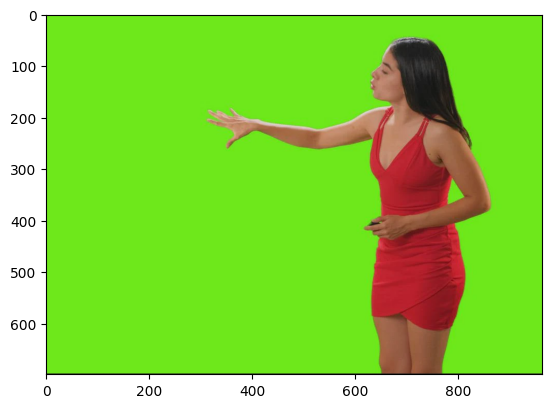

In [18]:
ob_image = cv2.imread('images/ob_image.png')

plt.imshow(cv2.cvtColor(ob_image, cv2.COLOR_BGR2RGB))
plt.show()

In [46]:
# check if the shape of 2 images are the same
print(bg_image1.shape)
print(bg_image2.shape)
print(ob_image.shape)

(699, 964, 3)
(495, 880, 3)
(699, 964, 3)


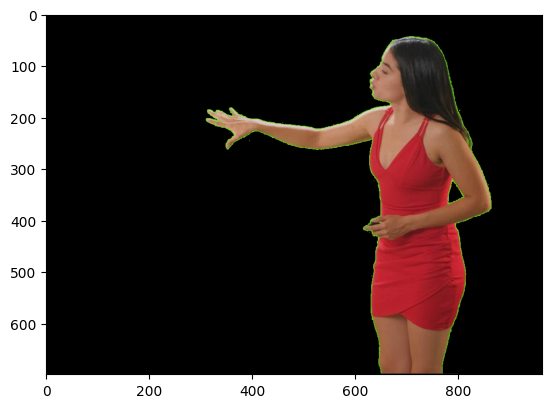

In [52]:
# create mask for person in ob_image by comparing with bg_image1
person_mask = np.zeros_like(ob_image)
alpha = 20

diff = np.abs(ob_image.astype(np.float32) - bg_image1.astype(np.float32))
background_pixels = np.all(diff <= alpha, axis=-1)
person_pixels = ~background_pixels

person_mask[person_pixels] = ob_image[person_pixels]

plt.imshow(cv2.cvtColor(person_mask, cv2.COLOR_BGR2RGB))
plt.show()

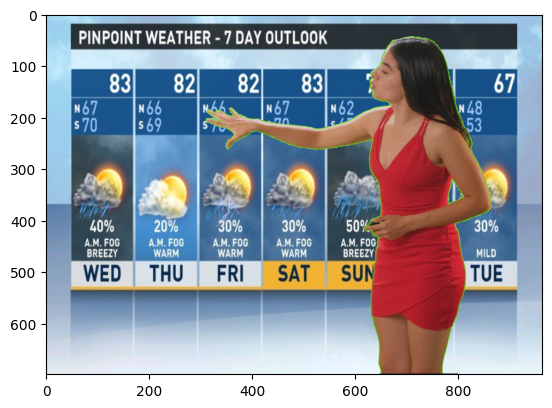

In [53]:
# copy person from ob_image to bg_image2 without resizing
result_image = bg_image2.copy()

bg_h, bg_w = result_image.shape[:2]
ob_h, ob_w = ob_image.shape[:2]

h = min(bg_h, ob_h)
w = min(bg_w, ob_w)

bg_y = (bg_h - h) // 2
bg_x = (bg_w - w) // 2
ob_y = (ob_h - h) // 2
ob_x = (ob_w - w) // 2

ob_crop = ob_image[ob_y:ob_y + h, ob_x:ob_x + w]
person_crop = person_pixels[ob_y:ob_y + h, ob_x:ob_x + w]
result_crop = result_image[bg_y:bg_y + h, bg_x:bg_x + w]

result_crop[person_crop] = ob_crop[person_crop]

plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.show()